<a href="https://colab.research.google.com/github/sapiree-hub/Hello2/blob/main/homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Your Name  
*NEUR 265*  
**March 7, 2026**

In [ ]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
# I need to load the dataset into a DataFrame
url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv(url)

# First few rows:
patch_seq.head()

,ISI,Fast_Trough,Marker
0,77.337143,-49.899998,Sst
1,17.177895,-44.462498,Sst
2,48.294737,-47.350002,Sst
3,8.980000,-45.656254,Sst
4,30.315385,-50.737499,Sst


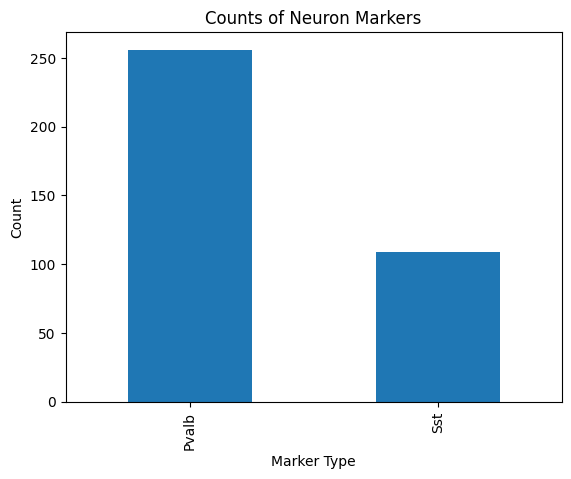

In [ ]:
# Bar graph of Marker value counts
patch_seq['Marker'].value_counts().plot(kind='bar')

plt.xlabel('Marker Type')
plt.ylabel('Count')
plt.title('# of Neuron Markers')
plt.show()

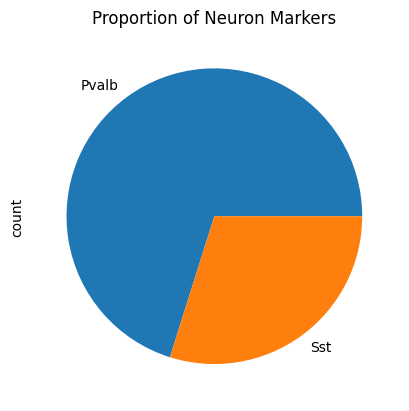

In [ ]:
# Pie chart of Marker value counts
patch_seq['Marker'].value_counts().plot(kind='pie')

plt.title('Proportion of Neuron Markers')
plt.show()

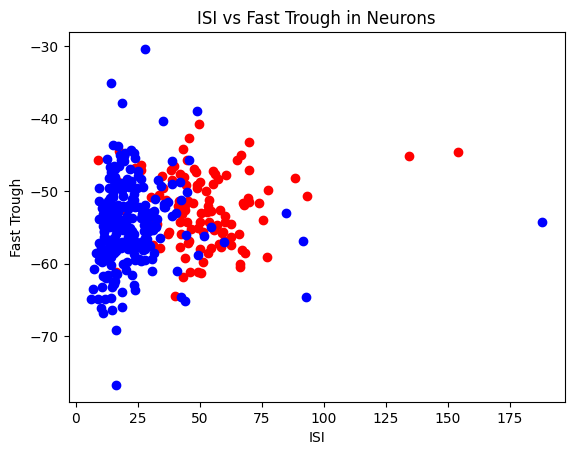

In [ ]:
# Scatter plot
for i in range(len(patch_seq)):
    if patch_seq['Marker'].iloc[i] == 'Sst':
        plt.scatter(patch_seq['ISI'].iloc[i], patch_seq['Fast_Trough'].iloc[i], color='red')
    elif patch_seq['Marker'].iloc[i] == 'Pvalb':
        plt.scatter(patch_seq['ISI'].iloc[i], patch_seq['Fast_Trough'].iloc[i], color='blue')

plt.xlabel('ISI')
plt.ylabel('Fast Trough')
plt.title('ISI vs Fast Trough in Neurons')
plt.show()

In [ ]:
#Function to call the scatter plot
def patchScatter():
  for i in range(len(patch_seq)):
    if patch_seq['Marker'].iloc[i] == 'Sst':
        plt.scatter(patch_seq['ISI'].iloc[i], patch_seq['Fast_Trough'].iloc[i], color='red')
    elif patch_seq['Marker'].iloc[i] == 'Pvalb':
        plt.scatter(patch_seq['ISI'].iloc[i], patch_seq['Fast_Trough'].iloc[i], color='blue')
  plt.xlabel('ISI')
  plt.ylabel('Fast Trough')
  plt.title('ISI vs Fast Trough in Neurons')
plt.show(patchScatter)

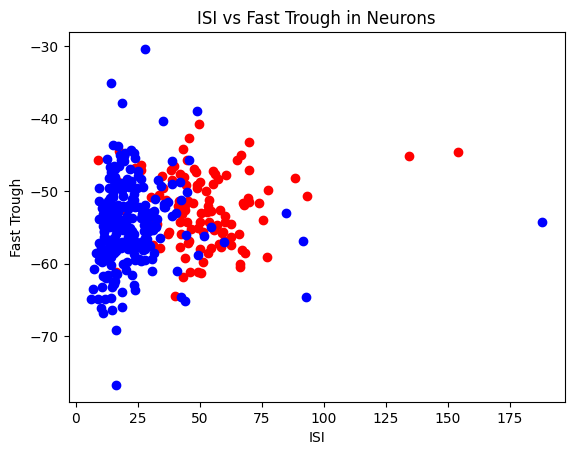

In [ ]:
patchScatter()

In [ ]:
# Summary for Fast Trough grouped by Marker
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


The mean Fast_Trough value for Pvalb neurons is more negative than for Sst neurons. This indicates that Sst has a stronger undershoot following an action potential.

If the skewness value is greater than 0.5 or less than -0.5, the distribution is skewed. Otherwise, it is normal.

In [ ]:
# Skewness of ISI
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


The skewness values indicate that both distributions are positively skewed, with Pvalb neurons showing a much stronger skew than Sst neurons. This suggests more extreme high-value outliers in the Pvalb Fast_Trough data.

In [ ]:
# Separate groups
sst_neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']

# Independent t-test
stats.ttest_ind(sst_neurons['Fast_Trough'],
                pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

# Separate groups
sst_neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']

# Independent t-test
stats.ttest_ind(sst_neurons['Fast_Trough'],
                pvalb_neurons['Fast_Trough'])

In [ ]:
# Remove Na values
sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()

# Independent t-test
stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))